# EDA 14.1: Revenue by Region and City Analysis

This notebook analyzes Revenue and order contribution by region and city, regional growth over time, geographic concentration, and leakage-safe historical geography-mix features for forecasting or explainability.

## 1. Setup and File Discovery

Locate required and optional CSV files under the current working directory. Missing files are reported and the notebook continues where possible.

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('default')
pd.set_option('display.max_columns', 240)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

ROOT = Path.cwd()
FILES = ['orders.csv', 'customers.csv', 'geography.csv', 'order_items.csv', 'sales.csv']
REQUIRED = {'orders.csv', 'customers.csv', 'geography.csv', 'order_items.csv'}

def normalize_name(name):
    return re.sub(r'[^a-z0-9]+', '', str(name).strip().lower())

def discover_csvs(root):
    found = {}
    for path in root.rglob('*.csv'):
        key = path.name.lower()
        if key not in found:
            found[key] = path
    return found

csv_files = discover_csvs(ROOT)
selected_paths = {name: csv_files.get(name.lower()) for name in FILES}
file_status = pd.DataFrame([
    {'file': name, 'required': name in REQUIRED, 'found': path is not None, 'path': str(path) if path else None}
    for name, path in selected_paths.items()
])
display(file_status)

for name, path in selected_paths.items():
    if path is None and name in REQUIRED:
        warnings.warn(f'Required file missing: {name}. The notebook will continue where possible.')

,file,required,found,path
0,orders.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
1,customers.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\cu...
2,geography.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\ge...
3,order_items.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
4,sales.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\sa...


## 2. Load Orders, Customers, Geography, Order Items, and Optional Sales

Load all available inputs safely with pandas and display schema summaries.

In [2]:
def load_csv_safe(path):
    if path is None:
        return None
    try:
        return pd.read_csv(path, low_memory=False)
    except Exception as exc:
        warnings.warn(f'Failed to load {path}: {exc}')
        return None

data = {name.replace('.csv', ''): load_csv_safe(path) for name, path in selected_paths.items()}
orders = data.get('orders')
customers = data.get('customers')
geography = data.get('geography')
order_items = data.get('order_items')
sales = data.get('sales')

schema_rows = []
for name, df in data.items():
    schema_rows.append({
        'dataset': name,
        'loaded': df is not None,
        'rows': None if df is None else len(df),
        'columns': None if df is None else ', '.join(map(str, df.columns[:20]))
    })
display(pd.DataFrame(schema_rows))

,dataset,loaded,rows,columns
0,orders,True,646945,"order_id, order_date, customer_id, zip, order_..."
1,customers,True,121930,"customer_id, zip, city, signup_date, gender, a..."
2,geography,True,39948,"zip, city, region, district"
3,order_items,True,714669,"order_id, product_id, quantity, unit_price, di..."
4,sales,True,3833,"Date, Revenue, COGS"


## 3. Identify Key, Date, Revenue, and Geography Columns

Use tolerant matching for likely naming variations. Revenue is reconstructed from `order_items` if needed.

In [3]:
def normalized_map(columns):
    return {normalize_name(c): c for c in columns}

def find_column(columns, candidates, contains=False):
    nmap = normalized_map(columns)
    normalized_candidates = [normalize_name(c) for c in candidates]
    for cand in normalized_candidates:
        if cand in nmap:
            return nmap[cand]
    if contains:
        for cand in normalized_candidates:
            for ncol, raw in nmap.items():
                if cand in ncol:
                    return raw
    return None

orders_cols = {}
if orders is not None:
    orders_cols = {
        'order_id': find_column(orders.columns, ['order_id']),
        'customer_id': find_column(orders.columns, ['customer_id']),
        'order_date': find_column(orders.columns, ['order_date', 'date', 'created_at'], contains=True),
        'zip': find_column(orders.columns, ['zip', 'postal_code', 'zipcode'], contains=True),
        'city': find_column(orders.columns, ['city']),
        'region': find_column(orders.columns, ['region', 'state', 'province']),
        'order_value': find_column(orders.columns, ['order_total', 'revenue', 'sales_amount', 'amount', 'total', 'gmv'], contains=True),
    }

customer_cols = {}
if customers is not None:
    customer_cols = {
        'customer_id': find_column(customers.columns, ['customer_id']),
        'zip': find_column(customers.columns, ['zip', 'postal_code', 'zipcode'], contains=True),
        'city': find_column(customers.columns, ['city']),
    }

geography_cols = {}
if geography is not None:
    geography_cols = {
        'zip': find_column(geography.columns, ['zip', 'postal_code', 'zipcode'], contains=True),
        'city': find_column(geography.columns, ['city']),
        'region': find_column(geography.columns, ['region', 'state', 'province']),
        'district': find_column(geography.columns, ['district']),
    }

order_item_cols = {}
if order_items is not None:
    order_item_cols = {
        'order_id': find_column(order_items.columns, ['order_id']),
        'product_id': find_column(order_items.columns, ['product_id']),
        'quantity': find_column(order_items.columns, ['quantity', 'qty', 'units'], contains=True),
        'price': find_column(order_items.columns, ['unit_price', 'price', 'selling_price'], contains=True),
        'discount': find_column(order_items.columns, ['discount_amount', 'discount'], contains=True),
        'amount': find_column(order_items.columns, ['revenue', 'item_total', 'line_total', 'sales_amount', 'net_sales'], contains=True),
    }

sales_cols = {}
if sales is not None:
    sales_cols = {
        'date': find_column(sales.columns, ['date', 'sales_date', 'order_date'], contains=True),
        'revenue': find_column(sales.columns, ['revenue', 'sales_amount', 'total_revenue'], contains=True),
    }

identified = pd.DataFrame({
    'orders': pd.Series(orders_cols),
    'customers': pd.Series(customer_cols),
    'geography': pd.Series(geography_cols),
    'order_items': pd.Series(order_item_cols),
    'sales': pd.Series(sales_cols),
})
display(identified)

,orders,customers,geography,order_items,sales
amount,NaN,NaN,NaN,None,NaN
city,None,city,city,NaN,NaN
customer_id,customer_id,customer_id,NaN,NaN,NaN
date,NaN,NaN,NaN,NaN,Date
discount,NaN,NaN,NaN,discount_amount,NaN
district,NaN,NaN,district,NaN,NaN
order_date,order_date,NaN,NaN,NaN,NaN
order_id,order_id,NaN,NaN,order_id,NaN
order_value,None,NaN,NaN,NaN,NaN
price,NaN,NaN,NaN,unit_price,NaN


## 4. Build Order-Level Revenue Dataset

Start from `orders` and reconstruct order Revenue from `order_items` where needed. This is the main geographic Revenue source.

In [4]:
geo_warnings = []
orders_clean = None
order_rev = pd.DataFrame()

if orders is not None:
    orders_clean = orders.copy()
    orders_clean['order_id_std'] = orders_clean[orders_cols['order_id']] if orders_cols.get('order_id') else pd.NA
    orders_clean['customer_id_std'] = orders_clean[orders_cols['customer_id']] if orders_cols.get('customer_id') else pd.NA
    orders_clean['order_date_std'] = pd.to_datetime(orders_clean[orders_cols['order_date']], errors='coerce') if orders_cols.get('order_date') else pd.NaT
    orders_clean['zip_std'] = orders_clean[orders_cols['zip']] if orders_cols.get('zip') else pd.NA
    orders_clean['city_order_std'] = orders_clean[orders_cols['city']] if orders_cols.get('city') else pd.NA
    orders_clean['region_order_std'] = orders_clean[orders_cols['region']] if orders_cols.get('region') else pd.NA
    orders_clean['order_revenue_raw'] = pd.to_numeric(orders_clean[orders_cols['order_value']], errors='coerce') if orders_cols.get('order_value') else np.nan

if order_items is not None and order_item_cols.get('order_id'):
    oi = order_items.copy()
    oi['order_id_std'] = oi[order_item_cols['order_id']]
    if order_item_cols.get('amount'):
        oi['item_revenue_std'] = pd.to_numeric(oi[order_item_cols['amount']], errors='coerce')
    else:
        qty = pd.to_numeric(oi[order_item_cols['quantity']], errors='coerce') if order_item_cols.get('quantity') else np.nan
        price = pd.to_numeric(oi[order_item_cols['price']], errors='coerce') if order_item_cols.get('price') else np.nan
        discount = pd.to_numeric(oi[order_item_cols['discount']], errors='coerce').fillna(0) if order_item_cols.get('discount') else 0
        oi['item_revenue_std'] = qty * price
    order_item_rev = oi.groupby('order_id_std').agg(
        order_revenue=('item_revenue_std', 'sum'),
        item_line_count=('order_id_std', 'size'),
    ).reset_index()
else:
    order_item_rev = pd.DataFrame(columns=['order_id_std', 'order_revenue', 'item_line_count'])

if orders_clean is not None:
    order_rev = orders_clean.merge(order_item_rev, on='order_id_std', how='left', indicator='item_merge')
    if order_rev['order_revenue_raw'].notna().sum() > 0:
        order_rev['order_revenue'] = order_rev['order_revenue_raw'].fillna(order_rev['order_revenue'])
        revenue_source = f"orders.{orders_cols['order_value']}"
    else:
        revenue_source = 'order_items reconstructed revenue'
    order_rev['order_count'] = 1

    quality = pd.DataFrame([{
        'revenue_source': revenue_source,
        'orders_with_missing_revenue': int(order_rev['order_revenue'].isna().sum()),
        'zero_or_negative_revenue_orders': int(order_rev['order_revenue'].fillna(0).le(0).sum()),
        'order_items_matched_to_orders': int((order_rev['item_merge'] == 'both').sum()),
        'order_items_unmatched_to_orders': int((~order_item_rev['order_id_std'].isin(orders_clean['order_id_std'])).sum()) if len(order_item_rev) else 0,
        'duplicate_order_ids': int(order_rev.duplicated(subset=['order_id_std']).sum()),
    }])
    display(quality)
    if quality.loc[0, 'orders_with_missing_revenue'] > 0:
        geo_warnings.append(f"{quality.loc[0, 'orders_with_missing_revenue']} orders have missing revenue")
    display(order_rev[['order_id_std', 'order_date_std', 'customer_id_std', 'order_revenue']].head(10))
else:
    warnings.warn('orders.csv not available.')

,revenue_source,orders_with_missing_revenue,zero_or_negative_revenue_orders,order_items_matched_to_orders,order_items_unmatched_to_orders,duplicate_order_ids
0,order_items reconstructed revenue,0,0,646945,0,0


,order_id_std,order_date_std,customer_id_std,order_revenue
0,1,2012-07-04,58578,"7,967.5400"
1,2,2012-07-04,58621,"71,163.7500"
2,3,2012-07-04,58811,"33,660.9900"
3,4,2012-07-04,59453,"53,196.2500"
4,6,2012-07-06,57821,"1,597.8400"
5,7,2012-07-06,57820,"9,800.9400"
6,8,2012-07-06,57818,"16,187.5600"
7,9,2012-07-06,49102,"32,397.1200"
8,10,2012-07-06,49101,"19,886.8500"
9,13,2012-07-06,40638,"36,037.6800"


## 5. Join Geography Information

Join orders to customers if needed, then join `geography` using ZIP/postal code. Use the most reliable city and region source available.

In [5]:
orders_geo = pd.DataFrame()

if customers is not None:
    customers_clean = customers.copy()
    customers_clean['customer_id_std'] = customers_clean[customer_cols['customer_id']] if customer_cols.get('customer_id') else pd.NA
    customers_clean['zip_customer_std'] = customers_clean[customer_cols['zip']] if customer_cols.get('zip') else pd.NA
    customers_clean['city_customer_std'] = customers_clean[customer_cols['city']] if customer_cols.get('city') else pd.NA
else:
    customers_clean = None

if geography is not None:
    geography_clean = geography.copy()
    geography_clean['zip_geo_std'] = geography_clean[geography_cols['zip']] if geography_cols.get('zip') else pd.NA
    geography_clean['city_geo_std'] = geography_clean[geography_cols['city']] if geography_cols.get('city') else pd.NA
    geography_clean['region_geo_std'] = geography_clean[geography_cols['region']] if geography_cols.get('region') else pd.NA
    geography_clean['district_geo_std'] = geography_clean[geography_cols['district']] if geography_cols.get('district') else pd.NA
    geography_clean = geography_clean.drop_duplicates(subset=['zip_geo_std'])
else:
    geography_clean = None

if not order_rev.empty:
    orders_geo = order_rev.copy()
    if customers_clean is not None and 'customer_id_std' in orders_geo.columns:
        orders_geo = orders_geo.merge(
            customers_clean[['customer_id_std', 'zip_customer_std', 'city_customer_std']],
            on='customer_id_std',
            how='left',
            indicator='customer_merge'
        )
    else:
        orders_geo['customer_merge'] = 'left_only'

    orders_geo['zip_join'] = orders_geo['zip_std'].fillna(orders_geo.get('zip_customer_std'))
    if geography_clean is not None:
        orders_geo = orders_geo.merge(
            geography_clean[['zip_geo_std', 'city_geo_std', 'region_geo_std', 'district_geo_std']],
            left_on='zip_join',
            right_on='zip_geo_std',
            how='left',
            indicator='geo_merge'
        )
    else:
        orders_geo['geo_merge'] = 'left_only'

    orders_geo['city_std'] = (
        orders_geo['city_order_std']
        .fillna(orders_geo.get('city_customer_std'))
        .fillna(orders_geo.get('city_geo_std'))
    )
    orders_geo['region_std'] = (
        orders_geo['region_order_std']
        .fillna(orders_geo.get('region_geo_std'))
    )
    orders_geo['city_std'] = orders_geo['city_std'].astype(str).str.strip()
    orders_geo['region_std'] = orders_geo['region_std'].astype(str).str.strip()
    orders_geo.loc[orders_geo['city_std'].isin(['nan', 'None', '']), 'city_std'] = np.nan
    orders_geo.loc[orders_geo['region_std'].isin(['nan', 'None', '']), 'region_std'] = np.nan

    join_quality = pd.DataFrame([{
        'orders_matched_to_customers': int((orders_geo['customer_merge'] == 'both').sum()),
        'orders_unmatched_to_customers': int((orders_geo['customer_merge'] == 'left_only').sum()),
        'rows_matched_to_geography': int((orders_geo['geo_merge'] == 'both').sum()),
        'rows_unmatched_to_geography': int((orders_geo['geo_merge'] == 'left_only').sum()),
        'missing_city_after_joins': int(orders_geo['city_std'].isna().sum()),
        'missing_region_after_joins': int(orders_geo['region_std'].isna().sum()),
    }])
    display(join_quality)
    unmatched_zips = orders_geo.loc[orders_geo['region_std'].isna(), ['order_id_std', 'zip_join']].drop_duplicates().head(10)
    if not unmatched_zips.empty:
        display(unmatched_zips)
    if join_quality.loc[0, 'missing_region_after_joins'] > 0:
        geo_warnings.append(f"{join_quality.loc[0, 'missing_region_after_joins']} orders still have missing region after joins")

,orders_matched_to_customers,orders_unmatched_to_customers,rows_matched_to_geography,rows_unmatched_to_geography,missing_city_after_joins,missing_region_after_joins
0,646945,0,646945,0,0,0


## 6. Join and Data Quality Checks

Summarize key missingness and duplicate risks after Revenue and geography joins.

In [6]:
if not orders_geo.empty:
    quality_summary = pd.DataFrame([{
        'row_count': len(orders_geo),
        'missing_order_ids': int(orders_geo['order_id_std'].isna().sum()),
        'missing_customer_ids': int(orders_geo['customer_id_std'].isna().sum()),
        'missing_zip_values': int(orders_geo['zip_join'].isna().sum()),
        'missing_city_values': int(orders_geo['city_std'].isna().sum()),
        'missing_region_values': int(orders_geo['region_std'].isna().sum()),
        'duplicate_order_ids': int(orders_geo.duplicated(subset=['order_id_std']).sum()),
        'zero_or_negative_revenue_orders': int(orders_geo['order_revenue'].fillna(0).le(0).sum()),
    }])
    display(quality_summary)

,row_count,missing_order_ids,missing_customer_ids,missing_zip_values,missing_city_values,missing_region_values,duplicate_order_ids,zero_or_negative_revenue_orders
0,646945,0,0,0,0,0,0,0


## 7. Revenue by Region

Rank regions by total Revenue, order count, Revenue share, order share, AOV, and customer-level contribution where available.

,region_std,total_revenue,order_count,AOV,customer_count,revenue_share,order_share,revenue_per_customer
1,East,"7,637,532,676.2000",294612,"25,924.0380",44721,0.4648,0.4554,"170,781.7955"
0,Central,"4,941,908,471.6800",184691,"26,757.7114",30784,0.3008,0.2855,"160,534.9685"
2,West,"3,851,035,437.6500",167642,"22,971.7818",14741,0.2344,0.2591,"261,246.5530"


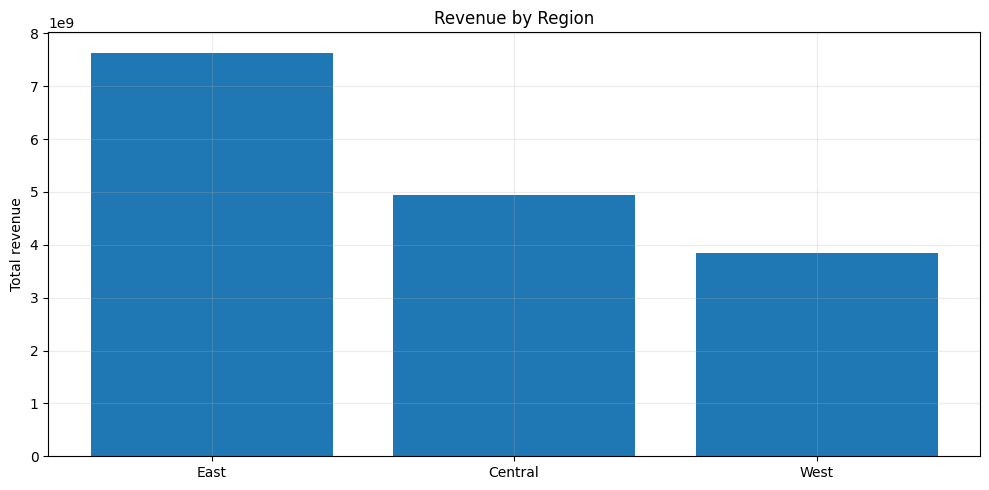

In [7]:
region_summary = pd.DataFrame()

if not orders_geo.empty and orders_geo['region_std'].notna().any():
    region_summary = orders_geo.groupby('region_std').agg(
        total_revenue=('order_revenue', 'sum'),
        order_count=('order_count', 'sum'),
        AOV=('order_revenue', 'mean'),
        customer_count=('customer_id_std', 'nunique'),
    ).reset_index()
    region_summary['revenue_share'] = region_summary['total_revenue'] / region_summary['total_revenue'].sum()
    region_summary['order_share'] = region_summary['order_count'] / region_summary['order_count'].sum()
    region_summary['revenue_per_customer'] = np.where(region_summary['customer_count'] > 0, region_summary['total_revenue'] / region_summary['customer_count'], np.nan)
    region_summary = region_summary.sort_values('total_revenue', ascending=False)
    display(region_summary)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(region_summary['region_std'].astype(str), region_summary['total_revenue'], color='tab:blue')
    ax.set_title('Revenue by Region')
    ax.set_ylabel('Total revenue')
    plt.tight_layout()
    plt.show()
else:
    print('Region-level Revenue analysis is unavailable because region could not be linked reliably.')

## 8. Order Count and Revenue by City

Rank cities by order count and Revenue and inspect whether a few cities dominate the business.

,city_std,total_revenue,order_count,AOV,customer_count,revenue_share,order_share
33,Son Tay,"581,180,750.8700",22473,"25,861.2891",3231,0.0354,0.0347
35,Thai Nguyen,"565,255,038.9800",21931,"25,774.2483",3341,0.0344,0.0339
22,Nam Dinh,"572,849,683.9000",21764,"26,320.9743",3178,0.0349,0.0336
14,Hanoi,"559,651,938.4500",21576,"25,938.6327",3180,0.0341,0.0334
27,Phu Ly,"559,747,301.1300",21330,"26,242.2551",3278,0.0341,0.0330
13,Hai Phong,"547,174,479.2600",21087,"25,948.4270",3211,0.0333,0.0326
24,Ninh Binh,"552,395,376.7400",21059,"26,230.8456",3100,0.0336,0.0326
12,Ha Long,"546,969,996.2500",21043,"25,992.9666",3251,0.0333,0.0325
39,Viet Tri,"544,927,319.4000",20889,"26,086.8074",3172,0.0332,0.0323
0,Bac Giang,"535,457,742.2600",20848,"25,683.8902",3239,0.0326,0.0322


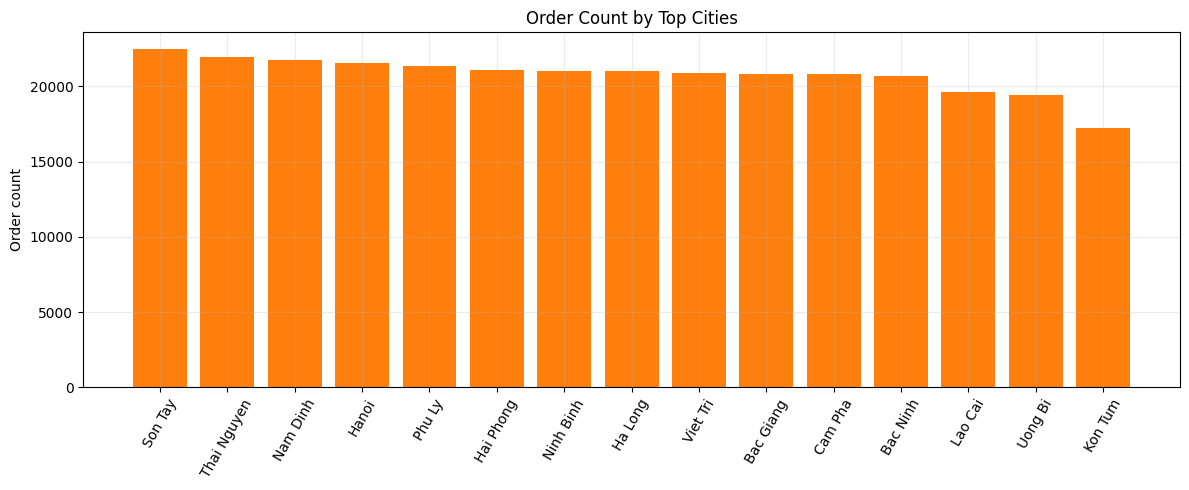

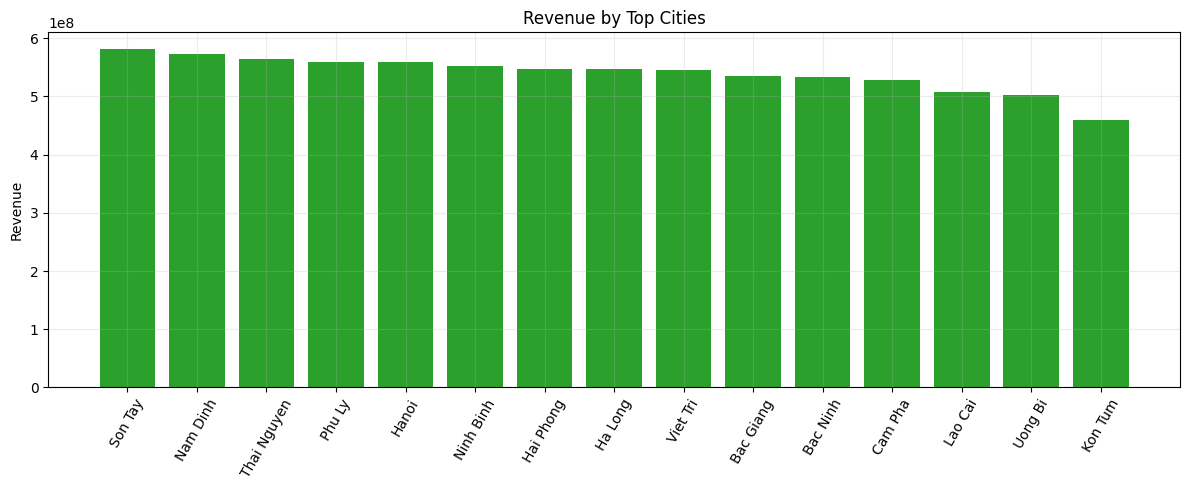

In [8]:
city_summary = pd.DataFrame()

if not orders_geo.empty and orders_geo['city_std'].notna().any():
    city_summary = orders_geo.groupby('city_std').agg(
        total_revenue=('order_revenue', 'sum'),
        order_count=('order_count', 'sum'),
        AOV=('order_revenue', 'mean'),
        customer_count=('customer_id_std', 'nunique'),
    ).reset_index()
    city_summary['revenue_share'] = city_summary['total_revenue'] / city_summary['total_revenue'].sum()
    city_summary['order_share'] = city_summary['order_count'] / city_summary['order_count'].sum()
    city_summary = city_summary.sort_values('order_count', ascending=False)
    display(city_summary.head(20))

    top_cities_orders = city_summary.head(15)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(top_cities_orders['city_std'].astype(str), top_cities_orders['order_count'], color='tab:orange')
    ax.set_title('Order Count by Top Cities')
    ax.set_ylabel('Order count')
    ax.tick_params(axis='x', rotation=60)
    plt.tight_layout()
    plt.show()

    top_cities_revenue = city_summary.sort_values('total_revenue', ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(top_cities_revenue['city_std'].astype(str), top_cities_revenue['total_revenue'], color='tab:green')
    ax.set_title('Revenue by Top Cities')
    ax.set_ylabel('Revenue')
    ax.tick_params(axis='x', rotation=60)
    plt.tight_layout()
    plt.show()
else:
    print('City-level analysis is unavailable because city could not be linked reliably.')

## 9. Geographic Concentration Analysis

Measure how concentrated Revenue is across regions and cities.

,region_std,total_revenue,order_count,AOV,customer_count,revenue_share,order_share,revenue_per_customer,cum_share
0,East,"7,637,532,676.2000",294612,"25,924.0380",44721,0.4648,0.4554,"170,781.7955",0.4648
1,Central,"4,941,908,471.6800",184691,"26,757.7114",30784,0.3008,0.2855,"160,534.9685",0.7656
2,West,"3,851,035,437.6500",167642,"22,971.7818",14741,0.2344,0.2591,"261,246.5530",1.0000


,city_std,total_revenue,order_count,AOV,customer_count,revenue_share,order_share,cum_share
0,Son Tay,"581,180,750.8700",22473,"25,861.2891",3231,0.0354,0.0347,0.0354
1,Nam Dinh,"572,849,683.9000",21764,"26,320.9743",3178,0.0349,0.0336,0.0702
2,Thai Nguyen,"565,255,038.9800",21931,"25,774.2483",3341,0.0344,0.0339,0.1046
3,Phu Ly,"559,747,301.1300",21330,"26,242.2551",3278,0.0341,0.0330,0.1387
4,Hanoi,"559,651,938.4500",21576,"25,938.6327",3180,0.0341,0.0334,0.1728
5,Ninh Binh,"552,395,376.7400",21059,"26,230.8456",3100,0.0336,0.0326,0.2064
6,Hai Phong,"547,174,479.2600",21087,"25,948.4270",3211,0.0333,0.0326,0.2397
7,Ha Long,"546,969,996.2500",21043,"25,992.9666",3251,0.0333,0.0325,0.2730
8,Viet Tri,"544,927,319.4000",20889,"26,086.8074",3172,0.0332,0.0323,0.3061
9,Bac Giang,"535,457,742.2600",20848,"25,683.8902",3239,0.0326,0.0322,0.3387


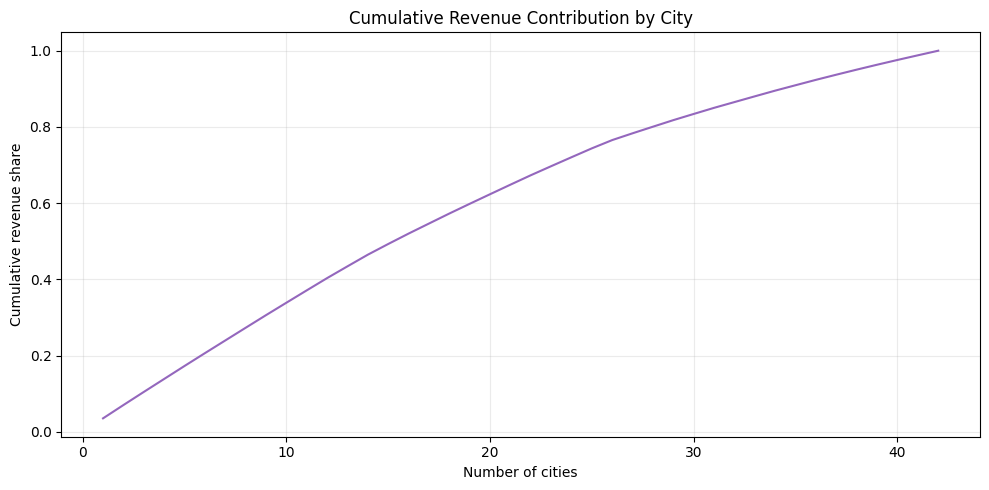

,level,top_1_share,top_3_share,top_5_share,units_to_50pct,units_to_80pct,units_to_90pct
0,region,0.4648,1.0000,NaN,2,3,3
1,city,0.0354,0.1046,0.1728,16,28,35


In [9]:
concentration_summary = []

def concentration_metrics(df, value_col, label):
    ordered = df.sort_values(value_col, ascending=False).reset_index(drop=True).copy()
    ordered['cum_share'] = ordered[value_col].cumsum() / ordered[value_col].sum()
    result = {
        'level': label,
        'top_1_share': ordered[value_col].head(1).sum() / ordered[value_col].sum(),
        'top_3_share': ordered[value_col].head(3).sum() / ordered[value_col].sum(),
        'top_5_share': ordered[value_col].head(5).sum() / ordered[value_col].sum() if len(ordered) >= 5 else np.nan,
    }
    for threshold in [0.5, 0.8, 0.9]:
        reached = int((ordered['cum_share'] < threshold).sum() + 1)
        result[f'units_to_{int(threshold*100)}pct'] = reached
    return ordered, result

region_contrib = pd.DataFrame()
city_contrib = pd.DataFrame()

if not region_summary.empty:
    region_contrib, region_metrics = concentration_metrics(region_summary, 'total_revenue', 'region')
    concentration_summary.append(region_metrics)
    display(region_contrib.head(10))

if not city_summary.empty:
    city_contrib, city_metrics = concentration_metrics(city_summary, 'total_revenue', 'city')
    concentration_summary.append(city_metrics)
    display(city_contrib.head(15))
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(np.arange(1, len(city_contrib) + 1), city_contrib['cum_share'], color='tab:purple')
    ax.set_title('Cumulative Revenue Contribution by City')
    ax.set_xlabel('Number of cities')
    ax.set_ylabel('Cumulative revenue share')
    plt.tight_layout()
    plt.show()

if concentration_summary:
    display(pd.DataFrame(concentration_summary))

## 10. Region Growth Over Time

Aggregate monthly Revenue by region and identify faster-growing or declining regions with enough volume.

,month,region_std,revenue,order_count,mom_growth
0,2012-07-01,Central,"42,346,424.9200",1543,NaN
1,2012-07-01,East,"61,481,999.6500",2542,NaN
2,2012-07-01,West,"26,578,348.9400",1209,NaN
3,2012-08-01,Central,"44,991,460.5700",1782,0.0625
4,2012-08-01,East,"77,151,645.6600",3088,0.2549
5,2012-08-01,West,"36,946,134.0800",1557,0.3901
6,2012-09-01,Central,"36,125,296.4600",1411,-0.1971
7,2012-09-01,East,"62,461,116.0200",2446,-0.1904
8,2012-09-01,West,"30,720,721.3400",1362,-0.1685
9,2012-10-01,Central,"30,227,334.1700",1109,-0.1633


,region_std,total_revenue,first_revenue,last_revenue,recent_3m_avg,early_3m_avg,month_count,first_last_growth,recent_vs_early_growth
0,Central,"4,941,908,471.6800","42,346,424.9200","17,418,852.5000","19,200,731.6500","41,154,393.9833",126,-0.5887,-0.5334
1,East,"7,637,532,676.2000","61,481,999.6500","22,177,101.5100","26,526,816.7967","67,031,587.1100",126,-0.6393,-0.6043


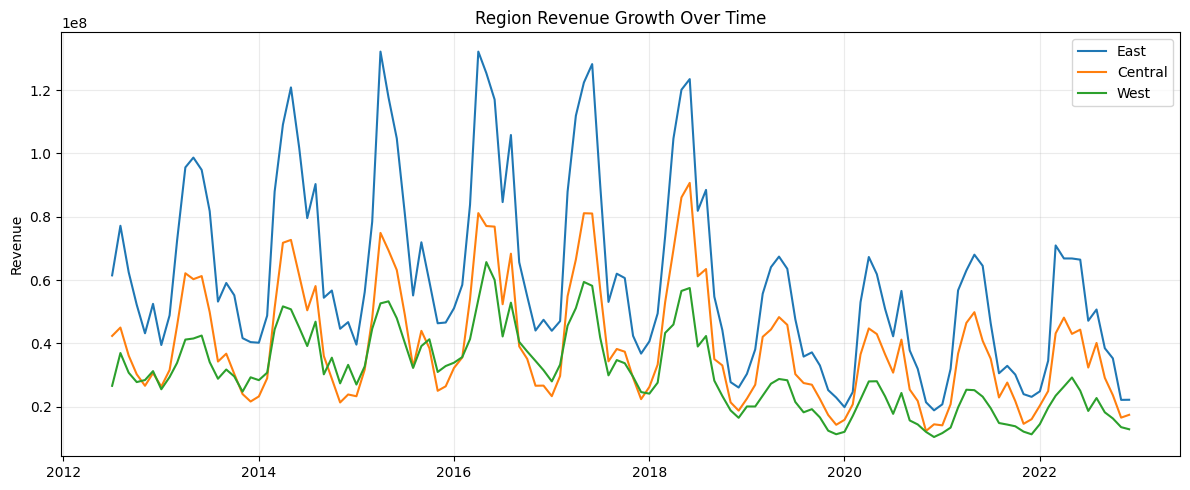

In [10]:
region_monthly = pd.DataFrame()
region_growth = pd.DataFrame()

if not orders_geo.empty and orders_geo['region_std'].notna().any() and orders_geo['order_date_std'].notna().any():
    orders_geo['month'] = orders_geo['order_date_std'].dt.to_period('M').dt.to_timestamp()
    region_monthly = orders_geo.groupby(['month', 'region_std']).agg(
        revenue=('order_revenue', 'sum'),
        order_count=('order_count', 'sum'),
    ).reset_index()
    region_monthly['mom_growth'] = region_monthly.groupby('region_std')['revenue'].pct_change()
    display(region_monthly.head(15))

    region_stats = region_monthly.groupby('region_std').agg(
        total_revenue=('revenue', 'sum'),
        first_revenue=('revenue', 'first'),
        last_revenue=('revenue', 'last'),
        recent_3m_avg=('revenue', lambda s: s.tail(3).mean()),
        early_3m_avg=('revenue', lambda s: s.head(3).mean()),
        month_count=('month', 'nunique'),
    ).reset_index()
    region_stats['first_last_growth'] = np.where(region_stats['first_revenue'] > 0, region_stats['last_revenue'] / region_stats['first_revenue'] - 1, np.nan)
    region_stats['recent_vs_early_growth'] = np.where(region_stats['early_3m_avg'] > 0, region_stats['recent_3m_avg'] / region_stats['early_3m_avg'] - 1, np.nan)
    region_growth = region_stats[region_stats['total_revenue'] >= region_stats['total_revenue'].median()].sort_values('recent_vs_early_growth', ascending=False)
    display(region_growth)

    top_regions = region_summary.head(3)['region_std'].tolist() if not region_summary.empty else []
    fig, ax = plt.subplots(figsize=(12, 5))
    for region in top_regions:
        tmp = region_monthly[region_monthly['region_std'] == region]
        ax.plot(tmp['month'], tmp['revenue'], label=region)
    ax.set_title('Region Revenue Growth Over Time')
    ax.set_ylabel('Revenue')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 11. City Growth and Emerging Markets

Identify cities with high current Revenue, fast recent growth, declining contribution, or small-but-growing contribution.

In [11]:
city_monthly = pd.DataFrame()
city_growth = pd.DataFrame()

if not orders_geo.empty and orders_geo['city_std'].notna().any() and orders_geo['order_date_std'].notna().any():
    city_monthly = orders_geo.groupby(['month', 'city_std']).agg(
        revenue=('order_revenue', 'sum'),
        order_count=('order_count', 'sum'),
    ).reset_index()
    city_monthly['mom_growth'] = city_monthly.groupby('city_std')['revenue'].pct_change()

    city_stats = city_monthly.groupby('city_std').agg(
        total_revenue=('revenue', 'sum'),
        current_revenue=('revenue', lambda s: s.tail(3).mean()),
        early_revenue=('revenue', lambda s: s.head(3).mean()),
        current_orders=('order_count', lambda s: s.tail(3).mean()),
        month_count=('month', 'nunique'),
    ).reset_index()
    city_stats['recent_growth'] = np.where(city_stats['early_revenue'] > 0, city_stats['current_revenue'] / city_stats['early_revenue'] - 1, np.nan)
    city_growth = city_stats[city_stats['month_count'] >= 6].sort_values('recent_growth', ascending=False)
    display(city_growth.head(20))

    high_current = city_growth.sort_values('current_revenue', ascending=False).head(10)
    emerging = city_growth[(city_growth['total_revenue'] < city_growth['total_revenue'].median())].sort_values('recent_growth', ascending=False).head(10)
    declining = city_growth.sort_values('recent_growth', ascending=True).head(10)
    print('High current Revenue cities')
    display(high_current)
    print('Emerging cities')
    display(emerging)
    print('Declining cities')
    display(declining)

,city_std,total_revenue,current_revenue,early_revenue,current_orders,month_count,recent_growth
37,Tuy Hoa,"356,887,198.3500","1,802,052.2300","2,591,878.1433",52.3333,126,-0.3047
4,Bien Hoa,"200,059,624.0800","949,944.3433","1,511,346.4433",30.0000,126,-0.3715
15,Ho Chi Minh City,"284,484,326.7600","1,293,977.7833","2,194,097.8167",40.3333,126,-0.4102
6,Ca Mau,"221,940,512.3300","1,003,755.4167","1,715,919.8733",37.3333,126,-0.4150
41,Vung Tau,"282,708,875.5300","1,180,095.6267","2,066,141.4600",41.3333,126,-0.4288
21,My Tho,"205,681,254.0000","758,539.8067","1,450,412.6533",28.6667,126,-0.4770
5,Buon Ma Thuot,"266,244,920.3700","1,021,805.3833","1,999,492.2533",36.3333,126,-0.4890
1,Bac Lieu,"248,060,537.6200","917,096.4733","1,825,000.0300",35.3333,126,-0.4975
30,Quy Nhon,"413,920,684.3800","1,780,912.8700","3,589,594.8500",57.6667,126,-0.5039
17,Hue,"448,967,772.6600","1,763,115.6500","3,693,716.0267",54.3333,126,-0.5227


High current Revenue cities


,city_std,total_revenue,current_revenue,early_revenue,current_orders,month_count,recent_growth
27,Phu Ly,"559,747,301.1300","2,207,317.6300","5,324,413.9867",70.3333,126,-0.5854
22,Nam Dinh,"572,849,683.9000","2,104,209.7733","4,662,082.9500",69.3333,126,-0.5487
14,Hanoi,"559,651,938.4500","2,097,664.2767","4,773,941.4200",66.6667,126,-0.5606
35,Thai Nguyen,"565,255,038.9800","1,997,504.3233","5,097,182.5767",66.0000,126,-0.6081
7,Cam Pha,"528,611,535.8600","1,985,728.2433","4,447,489.0067",65.0000,126,-0.5535
33,Son Tay,"581,180,750.8700","1,914,113.7100","5,032,681.2733",67.0000,126,-0.6197
12,Ha Long,"546,969,996.2500","1,869,840.9700","5,141,561.9633",67.3333,126,-0.6363
24,Ninh Binh,"552,395,376.7400","1,855,636.4567","4,593,514.5500",65.0000,126,-0.5960
38,Uong Bi,"502,280,290.7800","1,853,224.6067","4,277,141.0967",59.3333,126,-0.5667
13,Hai Phong,"547,174,479.2600","1,847,407.4367","4,975,181.0000",66.6667,126,-0.6287


Emerging cities


,city_std,total_revenue,current_revenue,early_revenue,current_orders,month_count,recent_growth
37,Tuy Hoa,"356,887,198.3500","1,802,052.2300","2,591,878.1433",52.3333,126,-0.3047
4,Bien Hoa,"200,059,624.0800","949,944.3433","1,511,346.4433",30.0000,126,-0.3715
15,Ho Chi Minh City,"284,484,326.7600","1,293,977.7833","2,194,097.8167",40.3333,126,-0.4102
6,Ca Mau,"221,940,512.3300","1,003,755.4167","1,715,919.8733",37.3333,126,-0.4150
41,Vung Tau,"282,708,875.5300","1,180,095.6267","2,066,141.4600",41.3333,126,-0.4288
21,My Tho,"205,681,254.0000","758,539.8067","1,450,412.6533",28.6667,126,-0.4770
5,Buon Ma Thuot,"266,244,920.3700","1,021,805.3833","1,999,492.2533",36.3333,126,-0.4890
1,Bac Lieu,"248,060,537.6200","917,096.4733","1,825,000.0300",35.3333,126,-0.4975
16,Hoi An,"406,486,900.7700","1,595,429.2600","3,371,680.4733",44.3333,126,-0.5268
23,Nha Trang,"390,722,171.9600","1,630,492.6767","3,481,023.0633",50.0000,126,-0.5316


Declining cities


,city_std,total_revenue,current_revenue,early_revenue,current_orders,month_count,recent_growth
36,Tra Vinh,"232,848,201.9900","648,763.1567","2,100,904.2667",26.6667,126,-0.6912
28,Pleiku,"292,164,028.8800","759,621.6100","2,423,262.0733",27.6667,126,-0.6865
19,Lao Cai,"507,781,252.7500","1,517,256.7667","4,765,507.3233",63.3333,126,-0.6816
8,Can Tho,"211,601,599.3500","576,260.8400","1,707,190.3767",24.0000,126,-0.6625
2,Bac Ninh,"533,249,969.5700","1,703,641.7900","4,921,842.1967",60.3333,126,-0.6539
39,Viet Tri,"544,927,319.4000","1,734,827.6867","4,801,322.9533",69.6667,126,-0.6387
12,Ha Long,"546,969,996.2500","1,869,840.9700","5,141,561.9633",67.3333,126,-0.6363
13,Hai Phong,"547,174,479.2600","1,847,407.4367","4,975,181.0000",66.6667,126,-0.6287
20,Long Xuyen,"263,588,656.0200","911,166.5000","2,403,999.6333",32.0000,126,-0.6210
33,Son Tay,"581,180,750.8700","1,914,113.7100","5,032,681.2733",67.0000,126,-0.6197


## 12. Optional Validation Against sales.csv

Use `sales.csv` only as a daily aggregate validation source. It cannot be joined directly to geography unless a geographic key exists.

In [12]:
sales_validation = pd.DataFrame()

if sales is not None and sales_cols.get('date') and sales_cols.get('revenue') and not orders_geo.empty and orders_geo['order_date_std'].notna().any():
    reconstructed_daily = orders_geo.groupby(orders_geo['order_date_std'].dt.floor('D')).agg(
        reconstructed_revenue=('order_revenue', 'sum')
    ).reset_index().rename(columns={'order_date_std': 'date'})

    sales_clean = sales.copy()
    sales_clean['date_std'] = pd.to_datetime(sales_clean[sales_cols['date']], errors='coerce')
    sales_clean['sales_revenue_std'] = pd.to_numeric(sales_clean[sales_cols['revenue']], errors='coerce')
    sales_daily = sales_clean.groupby('date_std').agg(sales_revenue=('sales_revenue_std', 'sum')).reset_index().rename(columns={'date_std': 'date'})

    sales_validation = reconstructed_daily.merge(sales_daily, on='date', how='inner')
    if not sales_validation.empty:
        sales_validation['difference'] = sales_validation['reconstructed_revenue'] - sales_validation['sales_revenue']
        validation_summary = pd.DataFrame([{
            'overlapping_days': len(sales_validation),
            'correlation': sales_validation['reconstructed_revenue'].corr(sales_validation['sales_revenue']),
            'total_difference': sales_validation['difference'].sum(),
            'mean_absolute_difference': sales_validation['difference'].abs().mean(),
        }])
        display(validation_summary)
        display(sales_validation.head(10))
        print('sales.csv is used only for validation here. It has no geographic key for regional analysis.')

,overlapping_days,correlation,total_difference,mean_absolute_difference
0,3833,1.0000,0.0000,0.0000


,date,reconstructed_revenue,sales_revenue,difference
0,2012-07-04,"5,123,547.9400","5,123,547.9400",0.0000
1,2012-07-05,"2,751,773.4500","2,751,773.4500",0.0000
2,2012-07-06,"3,054,029.4200","3,054,029.4200",0.0000
3,2012-07-07,"2,667,930.9400","2,667,930.9400",0.0000
4,2012-07-08,"2,360,851.9000","2,360,851.9000",0.0000
5,2012-07-09,"3,548,386.4600","3,548,386.4600",0.0000
6,2012-07-10,"5,234,938.6200","5,234,938.6200",0.0000
7,2012-07-11,"5,582,884.7800","5,582,884.7800",0.0000
8,2012-07-12,"5,734,632.0200","5,734,632.0200",0.0000
9,2012-07-13,"5,309,511.7100","5,309,511.7100",0.0000


sales.csv is used only for validation here. It has no geographic key for regional analysis.


## 13. Business Insight Discovery

Summarize practical geographic insights for marketing, logistics, and planning. These remain descriptive, not causal.

In [13]:
if not region_summary.empty:
    top_regions = region_summary.head(3)
    low_aov_high_orders = region_summary[(region_summary['AOV'] <= region_summary['AOV'].median()) & (region_summary['order_count'] >= region_summary['order_count'].median())]
    high_aov_low_orders = region_summary[(region_summary['AOV'] >= region_summary['AOV'].median()) & (region_summary['order_count'] <= region_summary['order_count'].median())]
    print('Core regions driving Revenue')
    display(top_regions)
    print('Regions with lower AOV but higher order volume')
    display(low_aov_high_orders)
    print('Regions with higher AOV but lower order volume')
    display(high_aov_low_orders)

if not city_summary.empty:
    top_city_orders = city_summary.sort_values('order_count', ascending=False).head(10)
    top_city_aov = city_summary.sort_values('AOV', ascending=False).head(10)
    print('Top cities by order volume')
    display(top_city_orders)
    print('Top cities by AOV')
    display(top_city_aov)

Core regions driving Revenue


,region_std,total_revenue,order_count,AOV,customer_count,revenue_share,order_share,revenue_per_customer
1,East,"7,637,532,676.2000",294612,"25,924.0380",44721,0.4648,0.4554,"170,781.7955"
0,Central,"4,941,908,471.6800",184691,"26,757.7114",30784,0.3008,0.2855,"160,534.9685"
2,West,"3,851,035,437.6500",167642,"22,971.7818",14741,0.2344,0.2591,"261,246.5530"


Regions with lower AOV but higher order volume


,region_std,total_revenue,order_count,AOV,customer_count,revenue_share,order_share,revenue_per_customer
1,East,"7,637,532,676.2000",294612,"25,924.0380",44721,0.4648,0.4554,"170,781.7955"


Regions with higher AOV but lower order volume


,region_std,total_revenue,order_count,AOV,customer_count,revenue_share,order_share,revenue_per_customer
0,Central,"4,941,908,471.6800",184691,"26,757.7114",30784,0.3008,0.2855,"160,534.9685"


Top cities by order volume


,city_std,total_revenue,order_count,AOV,customer_count,revenue_share,order_share
33,Son Tay,"581,180,750.8700",22473,"25,861.2891",3231,0.0354,0.0347
35,Thai Nguyen,"565,255,038.9800",21931,"25,774.2483",3341,0.0344,0.0339
22,Nam Dinh,"572,849,683.9000",21764,"26,320.9743",3178,0.0349,0.0336
14,Hanoi,"559,651,938.4500",21576,"25,938.6327",3180,0.0341,0.0334
27,Phu Ly,"559,747,301.1300",21330,"26,242.2551",3278,0.0341,0.0330
13,Hai Phong,"547,174,479.2600",21087,"25,948.4270",3211,0.0333,0.0326
24,Ninh Binh,"552,395,376.7400",21059,"26,230.8456",3100,0.0336,0.0326
12,Ha Long,"546,969,996.2500",21043,"25,992.9666",3251,0.0333,0.0325
39,Viet Tri,"544,927,319.4000",20889,"26,086.8074",3172,0.0332,0.0323
0,Bac Giang,"535,457,742.2600",20848,"25,683.8902",3239,0.0326,0.0322


Top cities by AOV


,city_std,total_revenue,order_count,AOV,customer_count,revenue_share,order_share
17,Hue,"448,967,772.6600",16405,"27,367.7399",2698,0.0273,0.0254
10,Da Nang,"382,821,348.2400",14262,"26,842.0522",2463,0.0233,0.0220
11,Dong Hoi,"419,202,921.1100",15626,"26,827.2700",2688,0.0255,0.0242
30,Quy Nhon,"413,920,684.3800",15442,"26,804.8623",2461,0.0252,0.0239
29,Quang Ngai,"432,698,461.6200",16160,"26,775.8949",2537,0.0263,0.0250
26,Phan Thiet,"431,610,617.0200",16133,"26,753.2769",2624,0.0263,0.0249
18,Kon Tum,"460,326,651.4200",17209,"26,749.1807",2693,0.0280,0.0266
37,Tuy Hoa,"356,887,198.3500",13355,"26,723.1148",2514,0.0217,0.0206
23,Nha Trang,"390,722,171.9600",14666,"26,641.3591",2464,0.0238,0.0227
25,Phan Rang-Thap Cham,"411,567,381.2900",15455,"26,630.0473",2554,0.0250,0.0239


## 14. Leakage-Safe Geography Forecast Feature Preview

Build lagged historical geography-mix features only. Future region or city mix must not be used directly unless it is known before prediction.

In [14]:
feature_preview = pd.DataFrame()

if not orders_geo.empty and orders_geo['order_date_std'].notna().any():
    daily_total = orders_geo.groupby(orders_geo['order_date_std'].dt.floor('D')).agg(
        total_revenue=('order_revenue', 'sum'),
        total_order_count=('order_count', 'sum'),
    ).reset_index().rename(columns={'order_date_std': 'date'})

    daily_region = orders_geo.groupby([orders_geo['order_date_std'].dt.floor('D'), 'region_std']).agg(
        revenue=('order_revenue', 'sum'),
        orders=('order_count', 'sum'),
    ).reset_index().rename(columns={'order_date_std': 'date'})
    daily_city = orders_geo.groupby([orders_geo['order_date_std'].dt.floor('D'), 'city_std']).agg(
        orders=('order_count', 'sum')
    ).reset_index().rename(columns={'order_date_std': 'date'})

    top_region_share = daily_region.groupby('date').apply(lambda d: d['revenue'].max() / d['revenue'].sum()).rename('top_region_revenue_share').reset_index()
    top_city_order_share = daily_city.groupby('date').apply(lambda d: d['orders'].max() / d['orders'].sum()).rename('top_city_order_share').reset_index()
    region_mix_concentration = daily_region.groupby('date').apply(lambda d: (d['revenue'] / d['revenue'].sum()).pow(2).sum()).rename('region_mix_concentration').reset_index()
    city_mix_concentration = daily_city.groupby('date').apply(lambda d: (d['orders'] / d['orders'].sum()).pow(2).sum()).rename('city_mix_concentration').reset_index()
    top_region_orders = daily_region.groupby('date')['orders'].max().rename('top_region_order_count').reset_index()
    top_city_orders = daily_city.groupby('date')['orders'].max().rename('top_city_order_count').reset_index()

    feat = daily_total.merge(top_region_share, on='date', how='left')
    feat = feat.merge(top_city_order_share, on='date', how='left')
    feat = feat.merge(region_mix_concentration, on='date', how='left')
    feat = feat.merge(city_mix_concentration, on='date', how='left')
    feat = feat.merge(top_region_orders, on='date', how='left')
    feat = feat.merge(top_city_orders, on='date', how='left')

    feat['region_revenue_share_lag'] = feat['top_region_revenue_share'].shift(1)
    feat['top_city_order_share_lag'] = feat['top_city_order_share'].shift(1)
    feat['region_mix_concentration_lag'] = feat['region_mix_concentration'].shift(1)
    feat['city_mix_concentration_lag'] = feat['city_mix_concentration'].shift(1)
    feat['top_region_order_count_lag'] = feat['top_region_order_count'].shift(1)
    feat['top_city_order_count_lag'] = feat['top_city_order_count'].shift(1)

    preview_cols = [
        'date', 'total_revenue', 'total_order_count', 'top_region_revenue_share',
        'top_city_order_share', 'region_revenue_share_lag', 'top_city_order_share_lag',
        'region_mix_concentration_lag', 'city_mix_concentration_lag',
        'top_region_order_count_lag', 'top_city_order_count_lag'
    ]
    feature_preview = feat[preview_cols].head(20)
    display(feature_preview)

print('All geography features shown above are lagged historical aggregates only.')
print('sales.csv daily aggregates cannot be joined directly to geography unless a valid geographic key exists.')
print('Do not use current-period or future region/city mix directly unless that mix is genuinely known before prediction.')

C:\Users\ACER\AppData\Local\Temp\ipykernel_14440\1922482861.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_region_share = daily_region.groupby('date').apply(lambda d: d['revenue'].max() / d['revenue'].sum()).rename('top_region_revenue_share').reset_index()


C:\Users\ACER\AppData\Local\Temp\ipykernel_14440\1922482861.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_city_order_share = daily_city.groupby('date').apply(lambda d: d['orders'].max() / d['orders'].sum()).rename('top_city_order_share').reset_index()


C:\Users\ACER\AppData\Local\Temp\ipykernel_14440\1922482861.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  region_mix_concentration = daily_region.groupby('date').apply(lambda d: (d['revenue'] / d['revenue'].sum()).pow(2).sum()).rename('region_mix_concentration').reset_index()


C:\Users\ACER\AppData\Local\Temp\ipykernel_14440\1922482861.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  city_mix_concentration = daily_city.groupby('date').apply(lambda d: (d['orders'] / d['orders'].sum()).pow(2).sum()).rename('city_mix_concentration').reset_index()


,date,total_revenue,total_order_count,top_region_revenue_share,top_city_order_share,region_revenue_share_lag,top_city_order_share_lag,region_mix_concentration_lag,city_mix_concentration_lag,top_region_order_count_lag,top_city_order_count_lag
0,2012-07-04,"5,123,547.9400",162,0.4217,0.0679,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,"2,751,773.4500",97,0.3792,0.0619,0.4217,0.0679,0.3527,0.0328,79.0000,11.0000
2,2012-07-06,"3,054,029.4200",93,0.5471,0.0645,0.3792,0.0619,0.3411,0.0352,42.0000,6.0000
3,2012-07-07,"2,667,930.9400",73,0.6187,0.1233,0.5471,0.0645,0.4178,0.0387,56.0000,6.0000
4,2012-07-08,"2,360,851.9000",88,0.4117,0.0795,0.6187,0.1233,0.4664,0.0512,38.0000,9.0000
5,2012-07-09,"3,548,386.4600",137,0.5090,0.0803,0.4117,0.0795,0.3443,0.0408,43.0000,7.0000
6,2012-07-10,"5,234,938.6200",183,0.4394,0.0546,0.5090,0.0803,0.3970,0.0369,69.0000,11.0000
7,2012-07-11,"5,582,884.7800",221,0.4793,0.0588,0.4394,0.0546,0.3589,0.0311,87.0000,10.0000
8,2012-07-12,"5,734,632.0200",246,0.4461,0.0569,0.4793,0.0588,0.3714,0.0309,105.0000,13.0000
9,2012-07-13,"5,309,511.7100",201,0.4069,0.0448,0.4461,0.0569,0.3696,0.0319,101.0000,14.0000


All geography features shown above are lagged historical aggregates only.
sales.csv daily aggregates cannot be joined directly to geography unless a valid geographic key exists.
Do not use current-period or future region/city mix directly unless that mix is genuinely known before prediction.


## 15. Key Observations and Warnings

Summarize geographic Revenue concentration, growth, validation, and recommended historical geography features.

In [15]:
summary_lines = ['KEY OBSERVATIONS AND WARNINGS']

if not region_summary.empty:
    top_regions = region_summary.head(3)
    summary_lines.append('- Top Revenue regions: ' + ', '.join(f"{r.region_std} ({r.total_revenue:,.2f})" for r in top_regions.itertuples()) + '.')

if not city_summary.empty:
    top_cities = city_summary.head(5)
    summary_lines.append('- Top order-count cities: ' + ', '.join(f"{r.city_std} ({int(r.order_count)})" for r in top_cities.itertuples()) + '.')

if concentration_summary:
    conc_df = pd.DataFrame(concentration_summary)
    city_row = conc_df[conc_df['level'] == 'city']
    region_row = conc_df[conc_df['level'] == 'region']
    if not region_row.empty and not city_row.empty:
        region_top3 = region_row['top_3_share'].iloc[0]
        city_top5 = city_row['top_5_share'].iloc[0]
        label = 'concentrated' if (region_top3 > 0.60 or city_top5 > 0.50) else 'broadly distributed'
        summary_lines.append(f'- Revenue is geographically {label} (top 3 regions share {region_top3:.2%}, top 5 cities share {city_top5:.2%}).')

if not region_growth.empty:
    valid_region_growth = region_growth[region_growth['recent_vs_early_growth'].notna()]
    if not valid_region_growth.empty:
        fastest = valid_region_growth.head(3)
        summary_lines.append('- Fastest-growing regions: ' + ', '.join(f"{r.region_std} ({r.recent_vs_early_growth:.2%})" for r in fastest.itertuples()) + '.')
    else:
        summary_lines.append('- Fastest-growing regions could not be ranked reliably because baseline growth periods are missing or zero.')

if not city_growth.empty:
    valid_city_growth = city_growth[city_growth['recent_growth'].notna()].copy()
    emerging = valid_city_growth[(valid_city_growth['total_revenue'] < valid_city_growth['total_revenue'].median())].sort_values('recent_growth', ascending=False).head(3)
    declining = valid_city_growth.sort_values('recent_growth', ascending=True).head(3)
    if not emerging.empty:
        summary_lines.append('- Emerging cities: ' + ', '.join(f"{r.city_std} ({r.recent_growth:.2%})" for r in emerging.itertuples()) + '.')
    else:
        summary_lines.append('- Emerging cities could not be ranked reliably from the available growth baseline.')
    if not declining.empty:
        summary_lines.append('- Declining cities: ' + ', '.join(f"{r.city_std} ({r.recent_growth:.2%})" for r in declining.itertuples()) + '.')
    else:
        summary_lines.append('- Declining cities could not be ranked reliably from the available growth baseline.')

if not sales_validation.empty:
    corr = sales_validation['reconstructed_revenue'].corr(sales_validation['sales_revenue'])
    total_diff = (sales_validation['reconstructed_revenue'] - sales_validation['sales_revenue']).sum()
    summary_lines.append(f'- Reconstructed order Revenue aligns with sales.csv at correlation {corr:.4f} with total difference {total_diff:,.2f}.')

if geo_warnings:
    summary_lines.append('- Geography data quality warnings: ' + '; '.join(geo_warnings))
else:
    summary_lines.append('- Geography data quality warnings: none beyond the checks reported in notebook tables.')

summary_lines.append('- Recommended leakage-safe geography forecast features: region_revenue_share_lag, top_city_order_share_lag, region_mix_concentration_lag, city_mix_concentration_lag, top_region_order_count_lag, and top_city_order_count_lag.')
summary_lines.append('- sales.csv daily aggregate cannot be joined directly to geography unless it has a valid geographic key.')
summary_lines.append('- Future region/city mix must not be used directly unless it is genuinely known before prediction.')
summary_lines.append('- Causal caution: this is observational EDA. Geographic performance can vary with demographics, channel mix, logistics reach, promotions, and assortment.')

print('\n'.join(summary_lines))

KEY OBSERVATIONS AND WARNINGS
- Top Revenue regions: East (7,637,532,676.20), Central (4,941,908,471.68), West (3,851,035,437.65).
- Top order-count cities: Son Tay (22473), Thai Nguyen (21931), Nam Dinh (21764), Hanoi (21576), Phu Ly (21330).
- Revenue is geographically concentrated (top 3 regions share 100.00%, top 5 cities share 17.28%).
- Fastest-growing regions: Central (-53.34%), East (-60.43%).
- Emerging cities: Tuy Hoa (-30.47%), Bien Hoa (-37.15%), Ho Chi Minh City (-41.02%).
- Declining cities: Tra Vinh (-69.12%), Pleiku (-68.65%), Lao Cai (-68.16%).
- Reconstructed order Revenue aligns with sales.csv at correlation 1.0000 with total difference 0.00.
- Geography data quality warnings: none beyond the checks reported in notebook tables.
- Recommended leakage-safe geography forecast features: region_revenue_share_lag, top_city_order_share_lag, region_mix_concentration_lag, city_mix_concentration_lag, top_region_order_count_lag, and top_city_order_count_lag.
- sales.csv daily a